In [63]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

In [64]:
ds = load_dataset("cambridgeltl/vsr_zeroshot")
df = ds["train"].to_pandas()

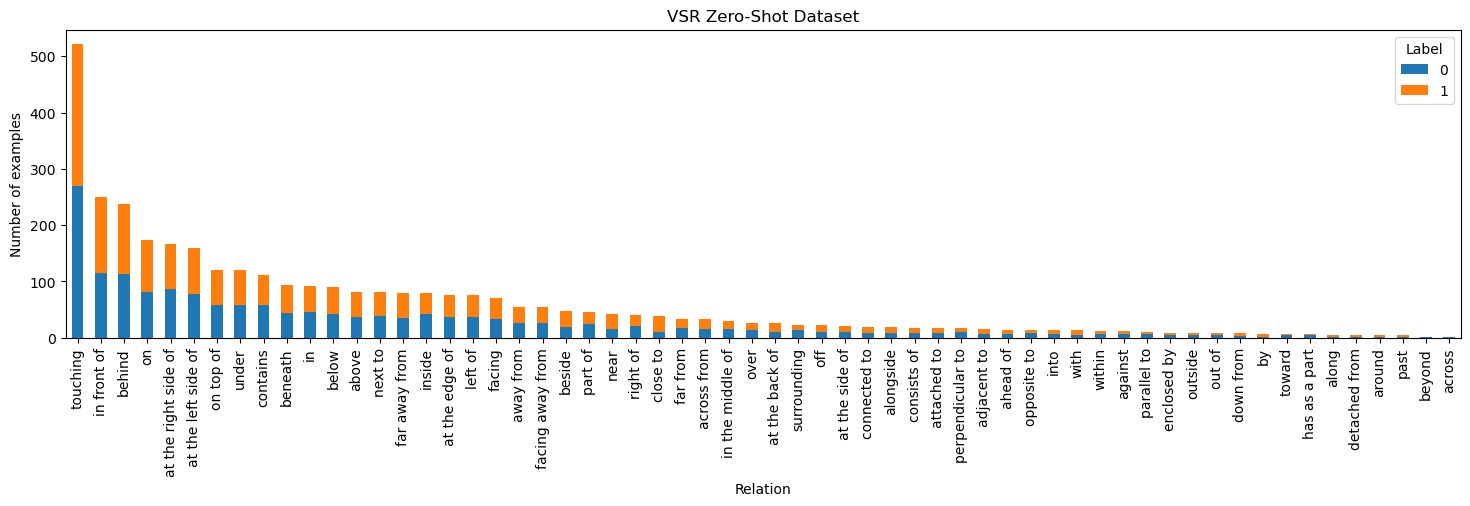

In [65]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])

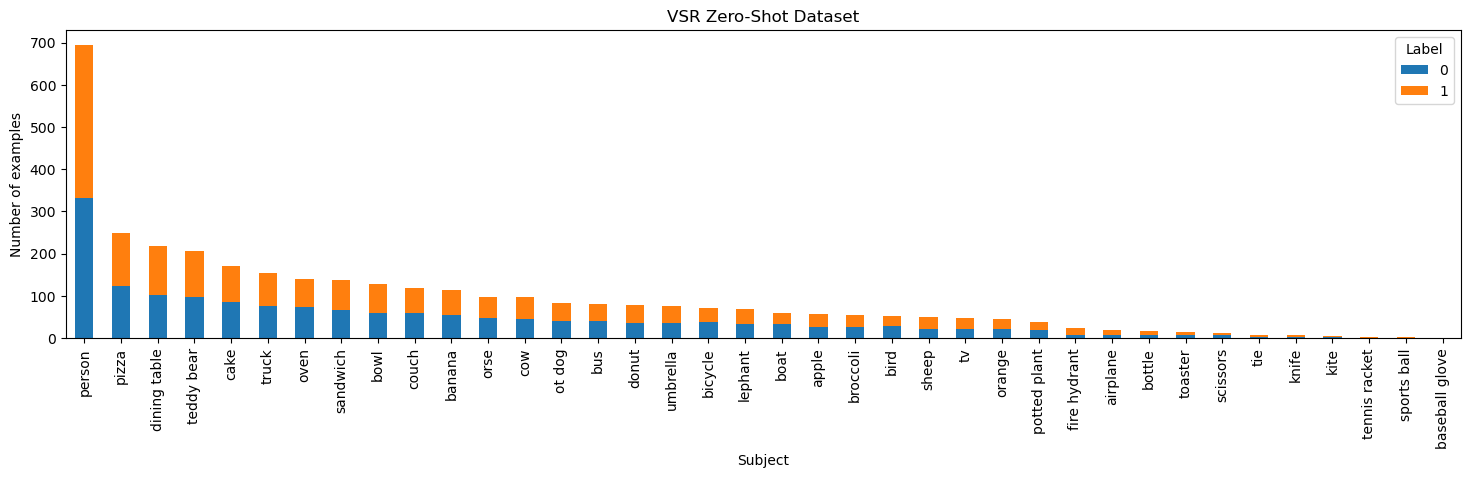

In [66]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['subj', 'label']].groupby(['subj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Subject")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

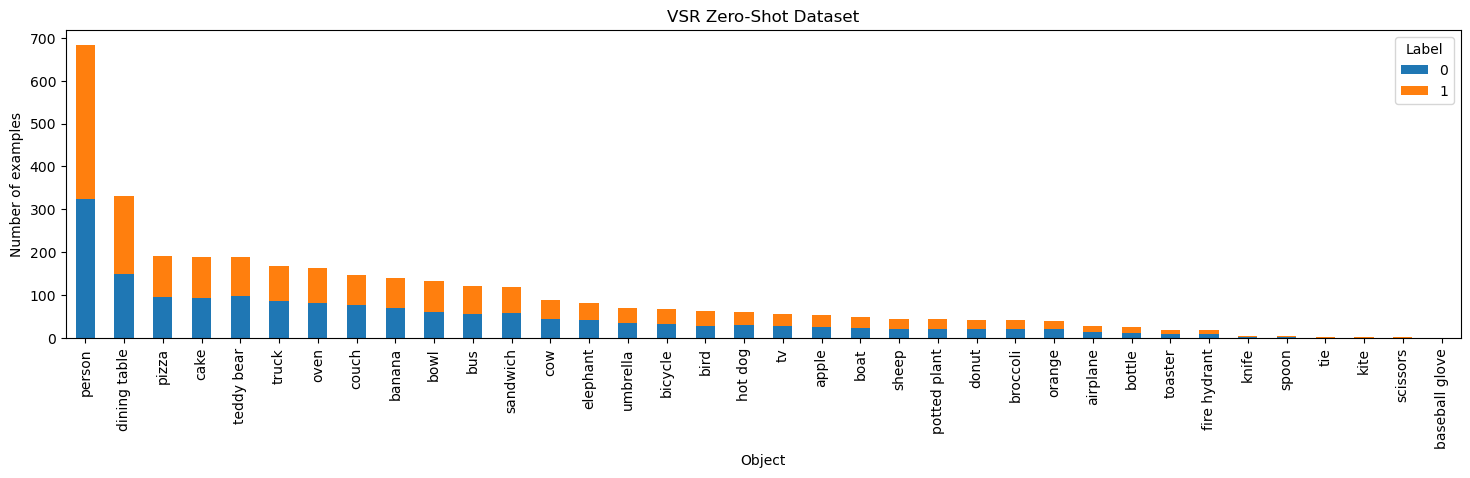

In [67]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['obj', 'label']].groupby(['obj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Object")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

# Under-Sampling

In [76]:
def undersample_by_relation(df,
                            keep_ratio=0.8,
                            seed=42):
    """
    For the listed relations:
      • keep **all** rows where label == minority_label
      • keep only `keep_ratio` of rows where label != minority_label
    All other relations are left untouched.
    """
    
    # Empty DataFrame to store the new data
    df_biased = pd.DataFrame(columns=df.columns)

    for rel, group in df.groupby('relation'):
        # Split into minority / majority within this relation
        group_count = group['label'].value_counts()
        
        minority_label = group_count.idxmin()
        majority_label = group_count.idxmax()
        
        group_min = group[group['label'] == minority_label]
        group_maj = group[group['label'] == majority_label]
        
        # Remove random from minority
        n_keep = int(len(group_min) * keep_ratio)
        n_drop = len(group_min) - n_keep
        if n_drop > 0:
            group_min_to_keep = group_min.sample(n=n_keep, random_state=seed)
        else:
            group_min_to_keep = group_min.sample(n=0, random_state=seed)
            
        new_group = pd.concat([group_maj, group_min_to_keep])
        df_biased = pd.concat([df_biased, new_group])  
        
    df_biased['label'] = df_biased['label'].astype('int')    
    
    return df_biased.reset_index(drop=True)

# Example: make 'touching', 'in front of', 'on' mostly positive
df_relation_biased = undersample_by_relation(df,
                                             keep_ratio=0.8)



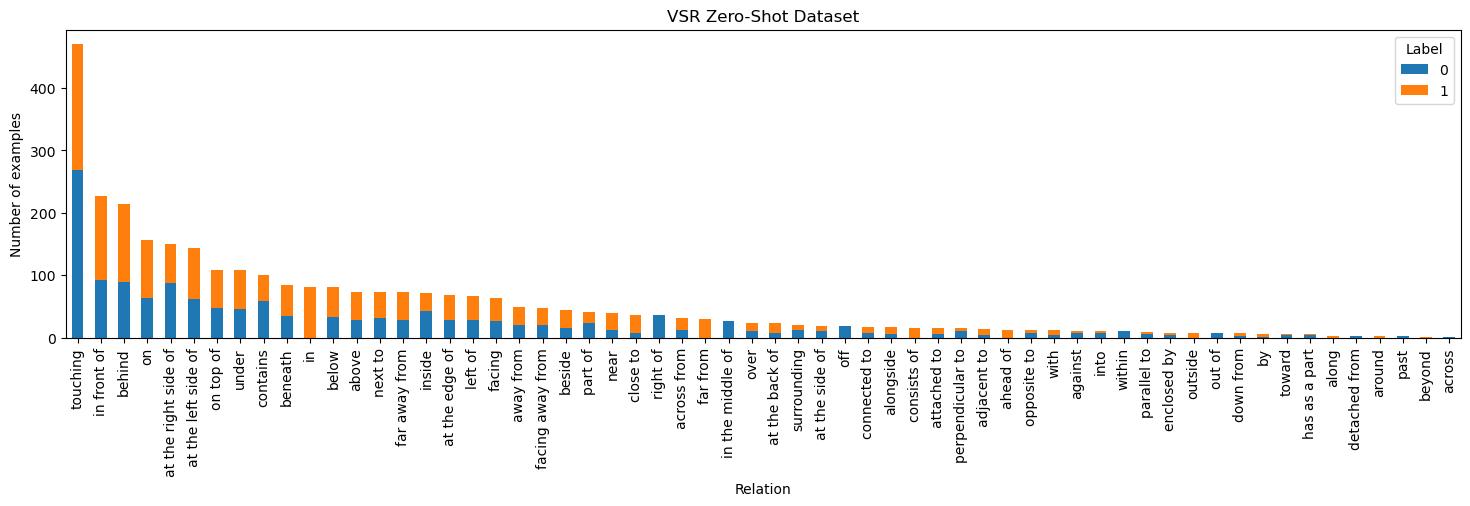

In [78]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df_relation_biased[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

In [79]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('label ~ relation', data=df_relation_biased).fit()
# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  label   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     6.664
Date:                Mon, 21 Apr 2025   Prob (F-statistic):           3.22e-47
Time:                        23:45:24   Log-Likelihood:                -2077.3
No. Observations:                3137   AIC:                             4275.
Df Residuals:                    3077   BIC:                             4638.
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# Add Vision Bias